In [1]:
import sys
print(sys.executable)

/Users/mdtahsinsharif/anaconda3/envs/stream-metrics/bin/python


In [2]:
import os
import tarfile
import shutil
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
# ===================== CONFIG =====================
query = "q7"
failure = "fails"
base_dir = Path("fails_flink")
output_dir = Path("analysis_output") / failure / query
window_seconds = 5
# ==================================================

In [4]:
output_dir.mkdir(parents=True, exist_ok=True)

print("[START] Analysis pipeline starting...")
print(f"Query: {query}")
print(f"Base dir: {base_dir}")
print(f"Output dir: {output_dir}")

pattern = f"nexmark_{failure}_10p_{query}_*.tar"
tar_files = list(base_dir.glob(pattern))

print(f"[INFO] Found {len(tar_files)} tar files")

if not tar_files:
    print(f"No tar files found for {query}")
    exit(1)

node_data = {}

[START] Analysis pipeline starting...
Query: q7
Base dir: fails_flink
Output dir: analysis_output/fails/q7
[INFO] Found 2 tar files


In [5]:
def compute_latency_summary(df):
    return {
        "avg": df["latency_ms"].mean(),
        "p50": df["latency_ms"].quantile(0.50),
        "p95": df["latency_ms"].quantile(0.95),
        "p99": df["latency_ms"].quantile(0.99),
    }

In [6]:
def parse_part_file(pf):
    rows = []
    bad = 0

    print(f"[FILE] Processing: {os.path.basename(pf)}")
    max_errors_to_show = 5
    error_count = 0
    with open(pf, "r", errors="ignore") as f:
        for line_num, line in enumerate(f, 1):
            parts = line.rstrip("\n").split(",", 5)

            if len(parts) < 4:
                bad += 1
                print(f"[WARN] Line {line_num}: insufficient columns -> {line.strip()}")
                continue

            auction, price, event_time, processed_time= parts

            try:
                rows.append({
                    "auction": int(auction),
                    "price": float(price),
                    "event_time": event_time,
                    "processed_time": processed_time
                })

            except Exception as e:
                bad += 1
                if error_count < max_errors_to_show:
                    print(f"[ERROR] Line {line_num}: {e}")
                    print(f"        data: {line.strip()}")
                    error_count += 1

    print(f"    -> parsed rows: {len(rows)} | bad rows: {bad}")
    return pd.DataFrame(rows)

In [7]:
# ===================== MAIN LOOP =====================
for tar_path in tar_files:
    tar_name = tar_path.stem
    node = tar_name.split("_")[-1]

    print("\n========================================")
    print(f"[TAR] Processing: {tar_name}")
    print(f"[NODE] Detected node: {node}")

    extract_root = base_dir / f"extracted_{tar_name}"
    temp_extract = base_dir / "_tmp_extract"

    flink_path = extract_root / "flink" / "nexmark" / query

    # -------- Extraction --------
    if extract_root.exists() and flink_path.exists():
        print(f"[SKIP] Already extracted: {extract_root}")
    else:
        if extract_root.exists():
            print("[CLEAN] Removing old extracted folder")
            shutil.rmtree(extract_root)

        if temp_extract.exists():
            shutil.rmtree(temp_extract)

        temp_extract.mkdir(parents=True, exist_ok=True)

        print(f"[EXTRACT] Extracting {tar_path}")
        with tarfile.open(tar_path) as tar:
            tar.extractall(path=temp_extract)

        print(f"[MOVE] Moving to {extract_root}")
        extract_root.mkdir(parents=True, exist_ok=True)

        extracted_items = list(temp_extract.iterdir())

        if len(extracted_items) == 1 and extracted_items[0].is_dir():
            shutil.move(str(extracted_items[0]), str(extract_root))
        else:
            for item in extracted_items:
                shutil.move(str(item), str(extract_root))

        shutil.rmtree(temp_extract)

    # -------- Data path --------
    data_path = extract_root / "mnt" / "nfs" / "flink" / "nexmark" / query
    print(f"[DATA] Looking in: {data_path}")

    part_files = sorted(glob.glob(str(data_path / "part-*")))
    print(f"[INFO] Found {len(part_files)} part files")

    if not part_files:
        print(f"[WARN] No part files for {node}")
        continue

    # -------- Load files --------
    dfs = []

    for pf in part_files:
        df_part = parse_part_file(pf)
        if not df_part.empty:
            dfs.append(df_part)

    if not dfs:
        print(f"[ERROR] No usable data for {node}")
        continue

    print(f"[MERGE] Concatenating {len(dfs)} dataframes...")
    df = pd.concat(dfs, ignore_index=True)
    print(f"[INFO] Total rows: {len(df)}")

    # -------- Clean timestamps --------
    print("[CLEAN] Converting timestamps...")
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df["processed_time"] = pd.to_datetime(df["processed_time"], errors="coerce")

    bad_rows = df["event_time"].isna() | df["processed_time"].isna()
    print(f"[CLEAN] Dropping bad rows: {bad_rows.sum()}")

    df = df[~bad_rows]

    # -------- Latency --------
    print("[CALC] Computing latency...")
    df["processed_time"] = df["processed_time"] + pd.Timedelta(hours=4)
    
    df["latency_ms"] = (
        (df["processed_time"] - df["event_time"])
        .dt.total_seconds() * 1000
    )

    print("[SORT] Sorting by processed_time...")
    df = df.sort_values("processed_time").set_index("processed_time")

    node_data[node] = df
    print(f"[DONE] Node {node} ready")
    
    print("\n================ LATENCY SUMMARY ================\n")

    global_df = []

    for node, df in node_data.items():
        stats = compute_latency_summary(df)

        print(f"[{node}]")
        print(f"  Avg latency : {stats['avg']:.2f} ms")
        print(f"  P50 latency : {stats['p50']:.2f} ms")
        print(f"  P95 latency : {stats['p95']:.2f} ms")
        print(f"  P99 latency : {stats['p99']:.2f} ms")
        print()



[TAR] Processing: nexmark_fails_10p_q7_n0
[NODE] Detected node: n0
[EXTRACT] Extracting fails_flink/nexmark_fails_10p_q7_n0.tar
[MOVE] Moving to fails_flink/extracted_nexmark_fails_10p_q7_n0
[DATA] Looking in: fails_flink/extracted_nexmark_fails_10p_q7_n0/mnt/nfs/flink/nexmark/q7
[INFO] Found 0 part files
[WARN] No part files for n0

[TAR] Processing: nexmark_fails_10p_q7_n1
[NODE] Detected node: n1
[EXTRACT] Extracting fails_flink/nexmark_fails_10p_q7_n1.tar
[MOVE] Moving to fails_flink/extracted_nexmark_fails_10p_q7_n1
[DATA] Looking in: fails_flink/extracted_nexmark_fails_10p_q7_n1/mnt/nfs/flink/nexmark/q7
[INFO] Found 0 part files
[WARN] No part files for n1


In [21]:
# ===================== ANALYSIS =====================
def smooth(series, w=5):
    return series.rolling(w, min_periods=1).mean()

def compute_latency(df):
    r = df["latency_ms"].resample(f"{window_seconds}s")
    return pd.DataFrame({
        "p50": r.quantile(0.5),
        "p95": r.quantile(0.95),
        "p99": r.quantile(0.99),
    })

def compute_throughput(df):
    return df["auction"].resample(f"{window_seconds}s").size()

def detect_failures(tp):
    gaps = []
    start = None

    for ts, v in tp.items():
        if v == 0 and start is None:
            start = ts
        elif v > 0 and start is not None:
            gaps.append((start, ts))
            start = None

    return gaps

In [22]:
# ===================== PLOTTING =====================
print("[PLOT] Latency plot...")
plt.figure()

node_colors = {"n0": "blue", "n1": "orange"}
all_failures = []

[PLOT] Latency plot...


<Figure size 640x480 with 0 Axes>

In [23]:
for node, df in node_data.items():
    lat = compute_latency(df)

    plt.plot(smooth(lat["p50"]), label=f"{node} p50", color=node_colors.get(node))
    plt.plot(smooth(lat["p95"]), linestyle="--", label=f"{node} p95", color=node_colors.get(node))
    plt.plot(smooth(lat["p99"]), linestyle=":", label=f"{node} p99", color=node_colors.get(node))

plt.title(f"Latency ({query})")
plt.xlabel("Time")
plt.ylabel("ms")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / f"latency_{query}.png")
plt.close()

print("[PLOT] Throughput plot...")
plt.figure()

[PLOT] Throughput plot...


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

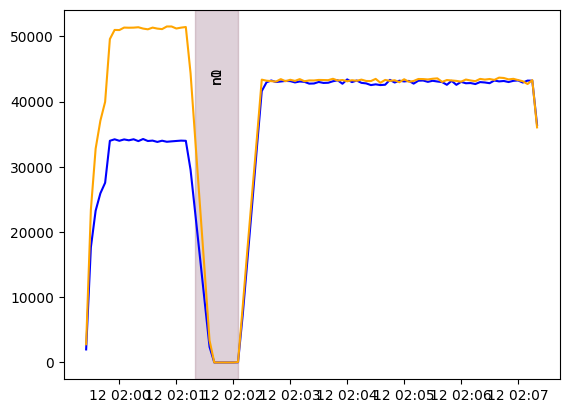

In [24]:
for node, df in node_data.items():
    tp = compute_throughput(df)
    tp_s = smooth(tp)

    plt.plot(tp_s, label=node, color=node_colors.get(node))

    gaps = detect_failures(tp)
    for start, end in gaps:
        all_failures.append((start, end, node))

for start, end, node in all_failures:
    plt.axvspan(start, end, alpha=0.15, color=node_colors.get(node))
    mid = start + (end - start) / 2
    plt.text(mid, plt.ylim()[1] * 0.8, f"{node}", rotation=90, ha="center")

In [25]:
plt.title(f"Throughput ({query})")
plt.xlabel("Time")
plt.ylabel("events/sec")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / f"throughput_{query}.png")
plt.close()

print("[COMPLETE] Done. Outputs in:", output_dir)

[COMPLETE] Done. Outputs in: analysis_output/fails/q2


/var/folders/q5/_vyqqcz16vg3sg5pn1mmprcw0000gn/T/ipykernel_13988/3772911770.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [26]:
df.head(2)

,auction,price,event_time,latency_ms
processed_time,,,,
2026-04-12 01:59:29.400,1107,1716.0,2026-04-12 01:59:25.522,3878.0
2026-04-12 01:59:29.403,1107,15087986.0,2026-04-12 01:59:25.524,3879.0
